In [1]:
# repositories
!git clone https://github.com/Luffy65/Semantic-Correspondence.git # Clone repo
!git clone https://github.com/facebookresearch/dinov3.git # DINOv3
!pip install git+https://github.com/facebookresearch/segment-anything.git # SAM
!git clone https://github.com/facebookresearch/dinov2.git # DINOv2

# Install requirements (requirements.txt)
!pip install -r Semantic-Correspondence/requirements.txt
!pip install -r dinov3/requirements.txt

Cloning into 'Semantic-Correspondence'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 322 (delta 67), reused 77 (delta 30), pack-reused 208 (from 1)
Receiving objects: 100% (322/322), 6.74 MiB | 18.61 MiB/s, done.
Resolving deltas: 100% (171/171), done.
Cloning into 'dinov3'...
remote: Enumerating objects: 538, done.
remote: Counting objects: 100% (363/363), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 538 (delta 201), reused 99 (delta 99), pack-reused 175 (from 1)
Receiving objects: 100% (538/538), 9.88 MiB | 4.03 MiB/s, done.
Resolving deltas: 100% (223/223), done.
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-0qo3xyxl
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-0qo3xyxl
  Resolved https://github.com/facebookresearch/segment-

In [2]:
# Dependencies
import os
import shutil
import gzip
import cv2
import json
from PIL import Image
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import time


In [3]:
# Connect google drive, load and unzip data
# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
DRIVE_ROOT = '/content/drive/MyDrive/AML-PROJECT-DATA/'
DATASET_ROOT = os.path.join(DRIVE_ROOT, 'dataset/')
DATASET_ARCHIVE = os.path.join(DATASET_ROOT, 'SPair-71k.tar.gz')
LOCAL_DATA_DIR = '/content/data'

# 3. Copy and Extract
if not os.path.exists(LOCAL_DATA_DIR):
    print(f"Extracting {DATASET_ARCHIVE} to local VM...")
    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

    # shutil works for .zip, .tar, .tar.gz, etc.
    # format='gztar' explicitly tells it to handle gzip compression
    shutil.unpack_archive(DATASET_ARCHIVE, LOCAL_DATA_DIR, format='gztar')

    print("Done! Data is ready at:", LOCAL_DATA_DIR)
else:
    print("Data already loaded.")

Mounted at /content/drive
Extracting /content/drive/MyDrive/AML-PROJECT-DATA/dataset/SPair-71k.tar.gz to local VM...
Done! Data is ready at: /content/data


In [4]:
# Setup and verify paths

SPAIR_ROOT = os.path.join(LOCAL_DATA_DIR, 'SPair-71k')

pair_ann_path = os.path.join(SPAIR_ROOT, 'PairAnnotation')
layout_path = os.path.join(SPAIR_ROOT, 'Layout')
image_path = os.path.join(SPAIR_ROOT, 'JPEGImages')

# Verify that paths exist
print(f"Verifying paths...")
print(f"  SPAIR_ROOT: {SPAIR_ROOT} → {'✓' if os.path.exists(SPAIR_ROOT) else '✗ DOES NOT EXIST'}")
print(f"  Layout: {layout_path} → {'✓' if os.path.exists(layout_path) else '✗ DOES NOT EXIST'}")
print(f"  PairAnnotation: {pair_ann_path} → {'✓' if os.path.exists(pair_ann_path) else '✗ DOES NOT EXIST'}")
print(f"  JPEGImages: {image_path} → {'✓' if os.path.exists(image_path) else '✗ DOES NOT EXIST'}")

# Verify that the trn.txt file exists
trn_file = os.path.join(layout_path, 'large', 'trn.txt')
print(f"  trn.txt: {trn_file} → {'✓' if os.path.exists(trn_file) else '✗ DOES NOT EXIST'}")

Verifying paths...
  SPAIR_ROOT: /content/data/SPair-71k → ✓
  Layout: /content/data/SPair-71k/Layout → ✓
  PairAnnotation: /content/data/SPair-71k/PairAnnotation → ✓
  JPEGImages: /content/data/SPair-71k/JPEGImages → ✓
  trn.txt: /content/data/SPair-71k/Layout/large/trn.txt → ✓


In [5]:
# Instantiate models
from segment_anything import SamPredictor, sam_model_registry
DINOV2_REPO_DIR = "dinov2"
DINOV3_REPO_DIR = "dinov3"
CHECKPOINTS_ROOT = os.path.join(DRIVE_ROOT, 'checkpoints/')
SAM_WEIGHTS_PATH = os.path.join(CHECKPOINTS_ROOT, 'sam_vit_b_01ec64.pth')
DINOV3_WEIGHTS_PATH = os.path.join(CHECKPOINTS_ROOT, 'dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth')
DINOV2_WEIGHT_PATH = os.path.join(CHECKPOINTS_ROOT, 'dinov2_vitb14_pretrain.pth')

sam = sam_model_registry["vit_b"](checkpoint=SAM_WEIGHTS_PATH)

sampredictor = SamPredictor(sam)
dinov2_vitb14 = torch.hub.load(DINOV2_REPO_DIR, 'dinov2_vitb14', source='local', weights=DINOV2_WEIGHT_PATH) # DINOv2 ViT model pretrained on web images
dinov3_vitb16 = torch.hub.load(DINOV3_REPO_DIR, 'dinov3_vitb16', source='local', weights=DINOV3_WEIGHTS_PATH) # DINOv3 ViT model pretrained on web images

/content/dinov2/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/content/dinov2/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/content/dinov2/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "file:///content/drive/.shortcut-targets-by-id/1fEWpONVft365O47IhEDLKZ2a0WkAuhyP/AML-PROJECT-DATA/checkpoints/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:04<00:00, 77.3MB/s]


Downloading: "file:///content/drive/.shortcut-targets-by-id/1fEWpONVft365O47IhEDLKZ2a0WkAuhyP/AML-PROJECT-DATA/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


100%|██████████| 327M/327M [00:06<00:00, 53.0MB/s]


In [6]:

sam = sam_model_registry["vit_b"](checkpoint=SAM_WEIGHTS_PATH)

sampredictor = SamPredictor(sam)
dinov2_vitb14 = torch.hub.load(DINOV2_REPO_DIR, 'dinov2_vitb14', source='local', weights=DINOV2_WEIGHT_PATH) # DINOv2 ViT model pretrained on web images
dinov3_vitb16 = torch.hub.load(DINOV3_REPO_DIR, 'dinov3_vitb16', source='local', weights=DINOV3_WEIGHTS_PATH) # DINOv3 ViT model pretrained on web images

In [ ]:
# Print models
print('======================models======================')
print(sam)
print('----------------------\n')
print(dinov2_vitb14)
print('----------------------\n')
print(dinov3_vitb16)
print('======================END print models======================')

======================models======================
Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=

First setup of chosen model before training

In [7]:
def setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze=2):
    """
    Freeze all layers except the last few

    Args:
        model: the model to finetune (dinov2_vitb14 , dinov3_vitb16 or SAM)
        model_type: 'dinov2', 'dinov3' or 'sam'
        num_layers_to_unfreeze: Number of last blocks to unfreeze
        head: if True, unfreeze norm layer for dino, neck for SAM
    """

    # First, freeze everything
    for param in model.parameters():
        param.requires_grad = False

    if 'dinov2' in model_type or 'dinov3' in model_type:
        total_blocks = len(model.blocks)
        print(f"Total DINO blocks: {total_blocks}")
        print(f"Unfreezing last {num_layers_to_unfreeze} blocks...")

        for i in range(total_blocks - num_layers_to_unfreeze, total_blocks):
            for param in model.blocks[i].parameters():
                param.requires_grad = True

        if head:
            for param in model.norm.parameters():
                param.requires_grad = True

    elif 'sam' in model_type:
        encoder = model.image_encoder
        if head:
            for param in encoder.neck.parameters():
                param.requires_grad = True

        total_blocks = len(model.image_encoder.blocks)
        print(f"Total SAM blocks: {total_blocks}")
        print(f"Unfreezing last {num_layers_to_unfreeze} blocks + neck...")

        for i in range(total_blocks - num_layers_to_unfreeze, total_blocks):
            for param in model.image_encoder.blocks[i].parameters():
                param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

    return model

Training logic

1.   extract descriptor
2.   train_epoch logic



In [8]:
#============= SIMPLIFIED TRAIN EPOCH (COMPLETE - FIXED AMP) =================
def train_epoch_simple(model, trainloader, optimizer, device, model_type, patch_size,
                      debug_batches=None, scaler=None, use_amp=False, accumulation_steps=1):
    """
    Training epoch without per-step LR scheduling (for use with ReduceLROnPlateau).
    Uses updated torch.amp API.
    """
    from torch.amp import autocast

    model.train()
    total_loss = 0
    num_batches = 0
    total_grad_norm = 0

    optimizer.zero_grad()

    for batch_idx, batch in enumerate(trainloader):
        if debug_batches is not None and batch_idx >= debug_batches:
            break

        src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)

        # Forward + backward with mixed precision
        if use_amp:
            with autocast(device_type='cuda'):
                src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
                trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

                B, Hf, Wf, C = src_feat.shape
                H_img, W_img = src_img.shape[2], src_img.shape[3]

                batch_loss = 0
                valid_kps_in_batch = 0

                for b in range(B):
                    sr_kps, tr_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

                    for k in range(sr_kps.shape[0]):
                        s_kp, t_kp = sr_kps[k], tr_kps[k]

                        if torch.isnan(s_kp).any() or s_kp[0] < 0:
                            continue

                        f_x = max(0, min(int(s_kp[0] / W_img * Wf), Wf - 1))
                        f_y = max(0, min(int(s_kp[1] / H_img * Hf), Hf - 1))

                        src_vec = src_feat[b, f_y, f_x]
                        sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec)

                        gt_fx = max(0, min(int(t_kp[0] / W_img * Wf), Wf - 1))
                        gt_fy = max(0, min(int(t_kp[1] / H_img * Hf), Hf - 1))
                        gt_idx = gt_fy * Wf + gt_fx

                        batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
                        valid_kps_in_batch += 1

                if valid_kps_in_batch > 0:
                    batch_loss = batch_loss / (valid_kps_in_batch * accumulation_steps)

            scaler.scale(batch_loss).backward()
        else:
            # Original code without AMP
            src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
            trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

            B, Hf, Wf, C = src_feat.shape
            H_img, W_img = src_img.shape[2], src_img.shape[3]

            batch_loss = 0
            valid_kps_in_batch = 0

            for b in range(B):
                sr_kps, tr_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

                for k in range(sr_kps.shape[0]):
                    s_kp, t_kp = sr_kps[k], tr_kps[k]

                    if torch.isnan(s_kp).any() or s_kp[0] < 0:
                        continue

                    f_x = max(0, min(int(s_kp[0] / W_img * Wf), Wf - 1))
                    f_y = max(0, min(int(s_kp[1] / H_img * Hf), Hf - 1))

                    src_vec = src_feat[b, f_y, f_x]
                    sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec)

                    gt_fx = max(0, min(int(t_kp[0] / W_img * Wf), Wf - 1))
                    gt_fy = max(0, min(int(t_kp[1] / H_img * Hf), Hf - 1))
                    gt_idx = gt_fy * Wf + gt_fx

                    batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
                    valid_kps_in_batch += 1

            if valid_kps_in_batch > 0:
                batch_loss = batch_loss / (valid_kps_in_batch * accumulation_steps)
                batch_loss.backward()

        # Update weights every N steps (gradient accumulation)
        if (batch_idx + 1) % accumulation_steps == 0:
            if use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad()

            # Compute gradient norm
            if valid_kps_in_batch > 0:
                grad_norm = 0
                for p in model.parameters():
                    if p.grad is not None and p.requires_grad:
                        param_norm = p.grad.data.norm(2)
                        grad_norm += param_norm.item() ** 2
                grad_norm = grad_norm ** 0.5
                total_grad_norm += grad_norm

        if valid_kps_in_batch > 0:
            total_loss += batch_loss.item() * accumulation_steps
            num_batches += 1

    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    avg_grad_norm = total_grad_norm / num_batches if num_batches > 0 else 0

    return avg_loss, avg_grad_norm


In [ ]:
# #============= SIMPLIFIED TRAIN EPOCH (for early stopping) COVERGENCE =================
# def train_epoch_simple(model, trainloader, optimizer, device, model_type, patch_size,
#                       debug_batches=None, scaler=None, use_amp=False, accumulation_steps=1):
#     """
#     Training epoch without per-step LR scheduling (for use with ReduceLROnPlateau).
#     """
#     from torch.cuda.amp import autocast

#     model.train()
#     total_loss = 0
#     num_batches = 0
#     total_grad_norm = 0

#     optimizer.zero_grad()

#     for batch_idx, batch in enumerate(trainloader):
#         if debug_batches is not None and batch_idx >= debug_batches:
#             break

#         src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)

#         # Forward + backward with mixed precision
#         if use_amp:
#             with autocast():
#                 src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
#                 trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

#                 B, Hf, Wf, C = src_feat.shape
#                 H_img, W_img = src_img.shape[2], src_img.shape[3]

#                 batch_loss = 0
#                 valid_kps_in_batch = 0

#                 for b in range(B):
#                     sr_kps, tr_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

#                     for k in range(sr_kps.shape[0]):
#                         s_kp, t_kp = sr_kps[k], tr_kps[k]

#                         if torch.isnan(s_kp).any() or s_kp[0] < 0:
#                             continue

#                         f_x = max(0, min(int(s_kp[0] / W_img * Wf), Wf - 1))
#                         f_y = max(0, min(int(s_kp[1] / H_img * Hf), Hf - 1))

#                         src_vec = src_feat[b, f_y, f_x]
#                         sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec)

#                         gt_fx = max(0, min(int(t_kp[0] / W_img * Wf), Wf - 1))
#                         gt_fy = max(0, min(int(t_kp[1] / H_img * Hf), Hf - 1))
#                         gt_idx = gt_fy * Wf + gt_fx

#                         batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
#                         valid_kps_in_batch += 1

#                 if valid_kps_in_batch > 0:
#                     batch_loss = batch_loss / (valid_kps_in_batch * accumulation_steps)

#             scaler.scale(batch_loss).backward()
#         else:
#             src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
#             trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

#             B, Hf, Wf, C = src_feat.shape
#             H_img, W_img = src_img.shape[2], src_img.shape[3]

#             batch_loss = 0
#             valid_kps_in_batch = 0

#             for b in range(B):
#                 sr_kps, tr_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

#                 for k in range(sr_kps.shape[0]):
#                     s_kp, t_kp = sr_kps[k], tr_kps[k]

#                     if torch.isnan(s_kp).any() or s_kp[0] < 0:
#                         continue

#                     f_x = max(0, min(int(s_kp[0] / W_img * Wf), Wf - 1))
#                     f_y = max(0, min(int(s_kp[1] / H_img * Hf), Hf - 1))

#                     src_vec = src_feat[b, f_y, f_x]
#                     sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec)

#                     gt_fx = max(0, min(int(t_kp[0] / W_img * Wf), Wf - 1))
#                     gt_fy = max(0, min(int(t_kp[1] / H_img * Hf), Hf - 1))
#                     gt_idx = gt_fy * Wf + gt_fx

#                     batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
#                     valid_kps_in_batch += 1

#             if valid_kps_in_batch > 0:
#                 batch_loss = batch_loss / (valid_kps_in_batch * accumulation_steps)
#                 batch_loss.backward()

#         # Update weights
#         if (batch_idx + 1) % accumulation_steps == 0:
#             if use_amp:
#                 scaler.step(optimizer)
#                 scaler.update()
#             else:
#                 optimizer.step()

#             optimizer.zero_grad()

#             # Compute gradient norm
#             if valid_kps_in_batch > 0:
#                 grad_norm = 0
#                 for p in model.parameters():
#                     if p.grad is not None and p.requires_grad:
#                         param_norm = p.grad.data.norm(2)
#                         grad_norm += param_norm.item() ** 2
#                 grad_norm = grad_norm ** 0.5
#                 total_grad_norm += grad_norm

#         if valid_kps_in_batch > 0:
#             total_loss += batch_loss.item() * accumulation_steps
#             num_batches += 1

#     avg_loss = total_loss / num_batches if num_batches > 0 else 0
#     avg_grad_norm = total_grad_norm / num_batches if num_batches > 0 else 0

#     return avg_loss, avg_grad_norm


In [9]:
#================= NEW  VALIDATE EPOCH====================================
def validate_epoch(model, valloader, device, model_type, patch_size,
                   thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=None, return_loss=False):
    """
    Validates the model and computes PCK accuracy at multiple thresholds.
    Now includes optional loss calculation for validation monitoring.
    """
    model.eval()
    correct = {t: 0 for t in thresholds}
    total = 0
    total_loss, loss_batches = 0, 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(valloader):
            if debug_batches is not None and batch_idx >= debug_batches:
                break

            src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)
            sf = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
            tf = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

            B, Hf, Wf, C = sf.shape
            Hi, Wi = src_img.shape[2], src_img.shape[3]

            for b in range(B):
                sk, tk = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)
                bbox = batch['trg_bbox'][b]
                norm = max(bbox[2] - bbox[0], bbox[3] - bbox[1]).item()

                for k in range(sk.shape[0]):
                    if torch.isnan(sk[k]).any() or sk[k, 0] < 0:
                        continue

                    # 1. Prediction
                    fx = max(0, min(int(sk[k, 0] / Wi * Wf), Wf - 1))
                    fy = max(0, min(int(sk[k, 1] / Hi * Hf), Hf - 1))
                    sim = torch.matmul(tf[b].reshape(-1, C), sf[b, fy, fx])
                    best_idx = torch.argmax(sim).item()

                    # 2. +0.5 Center Alignment
                    pred_x = ((best_idx % Wf) + 0.5) / Wf * Wi
                    pred_y = ((best_idx // Wf) + 0.5) / Hf * Hi

                    dist = torch.sqrt((pred_x - tk[k, 0])**2 + (pred_y - tk[k, 1])**2).item()
                    total += 1
                    for t in thresholds:
                        if dist < t * norm:
                            correct[t] += 1

                    # 3. Optional: Loss calculation
                    if return_loss:
                        gt_fx = max(0, min(int(tk[k, 0] / Wi * Wf), Wf - 1))
                        gt_fy = max(0, min(int(tk[k, 1] / Hi * Hf), Hf - 1))
                        total_loss += F.cross_entropy(sim.unsqueeze(0),
                                                     torch.tensor([gt_fy * Wf + gt_fx], device=device)).item()
                        loss_batches += 1

    pck_results = {t: (correct[t] / total * 100) if total > 0 else 0 for t in thresholds}
    avg_loss = total_loss / loss_batches if loss_batches > 0 else 0

    return pck_results, avg_loss  # Returns 2 values as expected by finetune


In [10]:
# # --- 3. Training Logic ---

def extract_descriptors(model, img, model_type, patch_size):
    """
    Extract dense features from the model
    Args:
        model: DINO or SAM model
        img: Input image tensor (B, 3, H, W) - already normalized by dataset
        model_type: 'dinov2' or 'sam'
        patch_size: Patch size of the model
    Returns:
        features: (B, H_feat, W_feat, C)
    """

    if 'dinov2' in model_type or 'dinov3' in model_type:

        res = model.forward_features(img)
        x = res['x_norm_patchtokens']
        B, N, C = x.shape
        H, W = img.shape[2] // patch_size, img.shape[3] // patch_size

        return x.reshape(B, H, W, C)

    elif 'sam' in model_type:

        # SAM expects images in range [0, 1], but your dataset normalizes to ImageNet stats
        # You may need to denormalize first if SAM doesn't work with normalized images

        x = model.image_encoder(img)
        return x.permute(0, 2, 3, 1) # (B, C, H, W) -> (B, H, W, C)
    return None

Custom SPair Dataset class

In [11]:
import sys
sys.path.append('/content/Semantic-Correspondence/datasets')

# Ora importa direttamente
from SPairDataset import SPairDataset


custom collate method

In [12]:
def custom_collate_fn(batch):
    """
    Manage batch with variable number of keypoints.
    """
    src_imgs = torch.stack([item['src_img'] for item in batch])
    trg_imgs = torch.stack([item['trg_img'] for item in batch])

    # Keypoints: list (variable number)
    src_kps = [item['src_kps'] for item in batch]
    trg_kps = [item['trg_kps'] for item in batch]

    # Bbox and threshold: can be stacked (fixed dimension)
    trg_bbox = torch.stack([item['trg_bbox'] for item in batch])  # (B, 4)
    pck_threshold = torch.tensor([item['pck_threshold'] for item in batch])  # (B,)

    categories = [item['category'] for item in batch]

    return {
        'src_img': src_imgs,
        'trg_img': trg_imgs,
        'src_kps': src_kps,
        'trg_kps': trg_kps,
        'trg_bbox': trg_bbox,
        'pck_threshold': pck_threshold,
        'category': categories
    }

Finetuning

In [13]:
#============= CHECKPOINT UTILITIES ================
def save_checkpoint(filepath, epoch, model, optimizer, scheduler, history,
                   best_pck, best_epoch, epochs_without_improvement, config):
    """Save training checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'best_pck': best_pck,
        'best_epoch': best_epoch,
        'epochs_without_improvement': epochs_without_improvement,
        'config': config,
    }
    torch.save(checkpoint, filepath)

def load_checkpoint(filepath, model, optimizer, scheduler, device):
    """Load training checkpoint and return state."""
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    return {
        'start_epoch': checkpoint['epoch'] + 1,
        'history': checkpoint['history'],
        'best_pck': checkpoint['best_pck'],
        'best_epoch': checkpoint['best_epoch'],
        'epochs_without_improvement': checkpoint['epochs_without_improvement'],
        'config': checkpoint['config'],
    }


In [14]:
#=================== FINETUNE WITH AUTO-CHECKPOINTING (COMPLETE - FIXED AMP) ============================
def finetune(
    model,
    pairann_path,
    layout_path,
    image_path,
    model_type,
    patch_size,
    head,
    learning_rate,
    num_layers_to_unfreeze,
    datasetsize='large',
    pck_alpha=0.1,
    num_epochs=20,
    batch_size=8,
    device='cuda',
    debug_batches=None,
    target_size=512,
    use_amp=True,
    use_compile=True,
    accumulation_steps=1,
    validate_every_n_epochs=1,
    early_stopping_patience=5,
    min_delta=0.1,
    reduce_lr_patience=3,
    reduce_lr_factor=0.5,
):
    """
    Complete Fine-tuning Loop with automatic checkpointing and resume capability.
    Uses updated torch.amp API.
    """
    from torch.amp import autocast, GradScaler

    # ✅ Define checkpoint paths
    CHECKPOINT_DIR = '/content/drive/MyDrive/AML-PROJECT-DATA/checkpoints'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    checkpoint_name = f"latest_{model_type}_layers{num_layers_to_unfreeze}.pth"
    checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)

    best_model_name = f"best_{model_type}_layers{num_layers_to_unfreeze}.pth"
    best_model_path = os.path.join(CHECKPOINT_DIR, best_model_name)

    print(f"\n{'='*70}")
    print(f"🚀 Starting Training: {model_type}")
    print(f"{'='*70}")
    print(f"Resolution: {target_size} | LR: {learning_rate} | Layers: {num_layers_to_unfreeze}")

    # 1. Setup Model
    model = setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze)
    model = model.to(device)

    if use_compile and not debug_batches:
        try:
            print("Compiling model...")
            model = torch.compile(model, mode='reduce-overhead')
            print("✓ Model compiled\n")
        except Exception as e:
            print(f"⚠️  Compilation failed: {e}\n")

    # 2. Prepare Data
    train_dataset = SPairDataset(pairann_path, layout_path, image_path,
                                 datasetsize, pck_alpha, datatype='trn', target_size=target_size)
    val_dataset = SPairDataset(pairann_path, layout_path, image_path,
                               datasetsize, pck_alpha, datatype='val', target_size=target_size)

    trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            num_workers=2, pin_memory=True, persistent_workers=True,
                            prefetch_factor=2, collate_fn=custom_collate_fn)
    valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True,
                          prefetch_factor=2, collate_fn=custom_collate_fn)

    # 3. Optimizer & Scheduler
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                 lr=learning_rate, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=reduce_lr_factor,
        patience=reduce_lr_patience, min_lr=1e-7
    )

    scaler = GradScaler(device='cuda') if use_amp else None

    # 4. Initialize History & Early Stopping State
    history = {
        'train_loss': [], 'val_loss': [],
        'train_pck_0.05': [], 'train_pck_0.10': [], 'train_pck_0.15': [], 'train_pck_0.20': [],
        'val_pck_0.05': [], 'val_pck_0.10': [], 'val_pck_0.15': [], 'val_pck_0.20': [],
        'grad_norm': [], 'learning_rates': [], 'validation_epochs': []
    }

    best_pck = 0.0
    best_epoch = 0
    epochs_without_improvement = 0
    start_epoch = 0

    # ✅ CHECK FOR EXISTING CHECKPOINT AND RESUME
    if os.path.exists(checkpoint_path):
        print(f"{'='*70}")
        print(f"📂 Found existing checkpoint: {checkpoint_name}")
        print(f"{'='*70}")
        try:
            state = load_checkpoint(checkpoint_path, model, optimizer, scheduler, device)
            start_epoch = state['start_epoch']
            history = state['history']
            best_pck = state['best_pck']
            best_epoch = state['best_epoch']
            epochs_without_improvement = state['epochs_without_improvement']

            print(f"✅ Resuming from epoch {start_epoch}")
            print(f"   Best PCK: {best_pck:.2f}% (Epoch {best_epoch})")
            print(f"   Epochs without improvement: {epochs_without_improvement}")
            print(f"{'='*70}\n")
        except Exception as e:
            print(f"⚠️  Failed to load checkpoint: {e}")
            print(f"Starting fresh training...\n")
            start_epoch = 0
    else:
        print(f"No checkpoint found. Starting fresh training.\n")

    # Save config for checkpoints
    config = {
        'model_type': model_type,
        'num_layers_to_unfreeze': num_layers_to_unfreeze,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'target_size': target_size,
    }

    print(f"Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
    print(f"Training: Epochs {start_epoch+1}-{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}\n")

    # ✅ TRAINING LOOP
    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()

        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"{'='*70}")

        # 1) Training
        train_loss, grad_norm = train_epoch_simple(
            model, trainloader, optimizer, device,
            model_type, patch_size, debug_batches=debug_batches,
            scaler=scaler, use_amp=use_amp, accumulation_steps=accumulation_steps
        )

        history['learning_rates'].append(optimizer.param_groups[0]['lr'])

        # 2) Validation
        should_validate = (epoch % validate_every_n_epochs == 0 or epoch == num_epochs - 1)

        if should_validate:
            history['validation_epochs'].append(epoch + 1)

            train_pck_results, _ = validate_epoch(
                model, trainloader, device, model_type, patch_size,
                thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=30, return_loss=False
            )

            val_pck_dict, val_loss = validate_epoch(
                model, valloader, device, model_type, patch_size,
                thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=debug_batches, return_loss=True
            )

            # Record metrics
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['grad_norm'].append(grad_norm)
            history['train_pck_0.05'].append(train_pck_results[0.05])
            history['train_pck_0.10'].append(train_pck_results[0.1])
            history['train_pck_0.15'].append(train_pck_results[0.15])
            history['train_pck_0.20'].append(train_pck_results[0.2])
            history['val_pck_0.05'].append(val_pck_dict[0.05])
            history['val_pck_0.10'].append(val_pck_dict[0.1])
            history['val_pck_0.15'].append(val_pck_dict[0.15])
            history['val_pck_0.20'].append(val_pck_dict[0.2])

            current_pck = val_pck_dict[0.1]
            duration = time.time() - epoch_start

            # Display results
            # ✅ Custom formatted output block
            print()
            print(f"✅ EPOCH {epoch+1}/{num_epochs} COMPLETE ({duration:.1f}s)")
            print("="*90)


            print("📉 LOSS:")
            print(f" Training: {train_loss:.4f}")
            print(f" Validation: {val_loss:.4f}")
            print(f" Grad Norm: {grad_norm:.2f}")


            print("\n🎯 PCK@0.1 (Main Metric):")
            print(f" Training: {train_pck_results[0.1]:.2f}%")
            print(f" Validation: {current_pck:.2f}%")


            print("\n📊 All PCK Thresholds (Validation):")
            print(f" @0.05: {val_pck_dict[0.05]:.2f}% | @0.10: {val_pck_dict[0.1]:.2f}% | "
            f"@0.15: {val_pck_dict[0.15]:.2f}% | @0.20: {val_pck_dict[0.2]:.2f}%")
            print("="*90)



            # Check improvement
            improvement = current_pck - best_pck

            if improvement > min_delta:
                best_pck = current_pck
                best_epoch = epoch + 1
                epochs_without_improvement = 0

                # ✅ Save best model
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'pck': best_pck,
                    'epoch': best_epoch,
                    'config': config,
                }, best_model_path)
                print(f" 🎉 NEW BEST! Saved to {best_model_name}")
            else:
                epochs_without_improvement += 1
                print(f" (no improvement: {epochs_without_improvement})")

            # LR scheduling
            old_lr = optimizer.param_groups[0]['lr']
            scheduler.step(current_pck)
            new_lr = optimizer.param_groups[0]['lr']
            if new_lr != old_lr:
                print(f"   📉 LR reduced: {old_lr:.2e} → {new_lr:.2e}")

            # ✅ Early stopping check
            if epochs_without_improvement >= early_stopping_patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
                print(f"   Best: {best_pck:.2f}% at epoch {best_epoch}")

                # ✅ Save final checkpoint
                save_checkpoint(checkpoint_path, epoch, model, optimizer, scheduler,
                              history, best_pck, best_epoch, epochs_without_improvement, config)
                print(f"   Final checkpoint saved: {checkpoint_name}")
                break
        else:
            print(f"Train Loss: {train_loss:.4f} (validation skipped)")

        # ✅ SAVE CHECKPOINT AFTER EVERY EPOCH
        save_checkpoint(checkpoint_path, epoch, model, optimizer, scheduler,
                       history, best_pck, best_epoch, epochs_without_improvement, config)
        print(f"💾 Checkpoint saved: {checkpoint_name}")

    # ✅ SAVE FINAL WEIGHTS WHEN TRAINING COMPLETES NORMALLY
    if epochs_without_improvement < early_stopping_patience:
        final_weights_path = os.path.join(CHECKPOINT_DIR, f"final_{model_type}_layers{num_layers_to_unfreeze}.pth")
        torch.save({
            'model_state_dict': model.state_dict(),
            'history': history,
            'best_pck': best_pck,
            'best_epoch': best_epoch,
            'final_epoch': epoch + 1,
            'config': config,
        }, final_weights_path)
        print(f"\n✅ Training complete! Final weights saved: final_{model_type}_layers{num_layers_to_unfreeze}.pth")

      # ✅ Final summary after training
    print(f"\n{'='*70}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"Best Validation PCK@0.1: {best_pck:.2f}% (Epoch {best_epoch})")
    print(f"Total epochs: {epoch+1}")
    print(f"Checkpoints saved in: {CHECKPOINT_DIR}")
    print(f"{'='*70}\n")


    return history


In [ ]:
# #=================== FINETUNE WITH AUTO-CHECKPOINTING ============================
# def finetune(
#     model,
#     pairann_path,
#     layout_path,
#     image_path,
#     model_type,
#     patch_size,
#     head,
#     learning_rate,
#     num_layers_to_unfreeze,
#     datasetsize='large',
#     pck_alpha=0.1,
#     num_epochs=20,
#     batch_size=8,
#     device='cuda',
#     debug_batches=None,
#     target_size=512,
#     use_amp=True,
#     use_compile=True,
#     accumulation_steps=1,
#     validate_every_n_epochs=1,
#     early_stopping_patience=5,
#     min_delta=0.1,
#     reduce_lr_patience=3,
#     reduce_lr_factor=0.5,
# ):
#     """
#     Fine-tuning with automatic checkpointing and resume capability.
#     """
#     from torch.cuda.amp import autocast, GradScaler

#     # ✅ Define checkpoint paths
#     CHECKPOINT_DIR = '/content/drive/MyDrive/AML-PROJECT-DATA/checkpoints'
#     os.makedirs(CHECKPOINT_DIR, exist_ok=True)

#     checkpoint_name = f"latest_{model_type}_layers{num_layers_to_unfreeze}.pth"
#     checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)

#     best_model_name = f"best_{model_type}_layers{num_layers_to_unfreeze}.pth"
#     best_model_path = os.path.join(CHECKPOINT_DIR, best_model_name)

#     print(f"\n{'='*70}")
#     print(f"🚀 Starting Training: {model_type}")
#     print(f"{'='*70}")

#     # 1. Setup Model
#     model = setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze)
#     model = model.to(device)

#     if use_compile and not debug_batches:
#         try:
#             print("Compiling model...")
#             model = torch.compile(model, mode='reduce-overhead')
#             print("✓ Model compiled\n")
#         except Exception as e:
#             print(f"⚠️  Compilation failed: {e}\n")

#     # 2. Prepare Data
#     train_dataset = SPairDataset(pairann_path, layout_path, image_path,
#                                  datasetsize, pck_alpha, datatype='trn', target_size=target_size)
#     val_dataset = SPairDataset(pairann_path, layout_path, image_path,
#                                datasetsize, pck_alpha, datatype='val', target_size=target_size)

#     trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
#                             num_workers=2, pin_memory=True, persistent_workers=True,
#                             prefetch_factor=2, collate_fn=custom_collate_fn)
#     valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
#                           num_workers=2, pin_memory=True, persistent_workers=True,
#                           prefetch_factor=2, collate_fn=custom_collate_fn)

#     # 3. Optimizer & Scheduler
#     optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
#                                  lr=learning_rate, weight_decay=1e-4)

#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode='max', factor=reduce_lr_factor,
#         patience=reduce_lr_patience, min_lr=1e-7
#     )

#     scaler = GradScaler() if use_amp else None

#     # 4. Initialize History & Early Stopping State
#     history = {
#         'train_loss': [], 'val_loss': [],
#         'train_pck_0.05': [], 'train_pck_0.10': [], 'train_pck_0.15': [], 'train_pck_0.20': [],
#         'val_pck_0.05': [], 'val_pck_0.10': [], 'val_pck_0.15': [], 'val_pck_0.20': [],
#         'grad_norm': [], 'learning_rates': [], 'validation_epochs': []
#     }

#     best_pck = 0.0
#     best_epoch = 0
#     epochs_without_improvement = 0
#     start_epoch = 0

#     # ✅ CHECK FOR EXISTING CHECKPOINT AND RESUME
#     if os.path.exists(checkpoint_path):
#         print(f"{'='*70}")
#         print(f"📂 Found existing checkpoint: {checkpoint_name}")
#         print(f"{'='*70}")
#         try:
#             state = load_checkpoint(checkpoint_path, model, optimizer, scheduler, device)
#             start_epoch = state['start_epoch']
#             history = state['history']
#             best_pck = state['best_pck']
#             best_epoch = state['best_epoch']
#             epochs_without_improvement = state['epochs_without_improvement']

#             print(f"✅ Resuming from epoch {start_epoch}")
#             print(f"   Best PCK: {best_pck:.2f}% (Epoch {best_epoch})")
#             print(f"   Epochs without improvement: {epochs_without_improvement}")
#             print(f"{'='*70}\n")
#         except Exception as e:
#             print(f"⚠️  Failed to load checkpoint: {e}")
#             print(f"Starting fresh training...\n")
#             start_epoch = 0
#     else:
#         print(f"No checkpoint found. Starting fresh training.\n")

#     # Save config for checkpoints
#     config = {
#         'model_type': model_type,
#         'num_layers_to_unfreeze': num_layers_to_unfreeze,
#         'learning_rate': learning_rate,
#         'batch_size': batch_size,
#         'target_size': target_size,
#     }

#     print(f"Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
#     print(f"Training: Epochs {start_epoch+1}-{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}\n")

#     # ✅ TRAINING LOOP
#     for epoch in range(start_epoch, num_epochs):
#         epoch_start = time.time()

#         print(f"\n{'='*70}")
#         print(f"Epoch {epoch+1}/{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")
#         print(f"{'='*70}")

#         # 1) Training
#         train_loss, grad_norm = train_epoch_simple(
#             model, trainloader, optimizer, device,
#             model_type, patch_size, debug_batches=debug_batches,
#             scaler=scaler, use_amp=use_amp, accumulation_steps=accumulation_steps
#         )

#         history['learning_rates'].append(optimizer.param_groups[0]['lr'])

#         # 2) Validation
#         should_validate = (epoch % validate_every_n_epochs == 0 or epoch == num_epochs - 1)

#         if should_validate:
#             history['validation_epochs'].append(epoch + 1)

#             train_pck_results, _ = validate_epoch(
#                 model, trainloader, device, model_type, patch_size,
#                 thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=30, return_loss=False
#             )

#             val_pck_dict, val_loss = validate_epoch(
#                 model, valloader, device, model_type, patch_size,
#                 thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=debug_batches, return_loss=True
#             )

#             # Record metrics
#             history['train_loss'].append(train_loss)
#             history['val_loss'].append(val_loss)
#             history['grad_norm'].append(grad_norm)
#             history['train_pck_0.05'].append(train_pck_results[0.05])
#             history['train_pck_0.10'].append(train_pck_results[0.1])
#             history['train_pck_0.15'].append(train_pck_results[0.15])
#             history['train_pck_0.20'].append(train_pck_results[0.2])
#             history['val_pck_0.05'].append(val_pck_dict[0.05])
#             history['val_pck_0.10'].append(val_pck_dict[0.1])
#             history['val_pck_0.15'].append(val_pck_dict[0.15])
#             history['val_pck_0.20'].append(val_pck_dict[0.2])

#             current_pck = val_pck_dict[0.1]
#             duration = time.time() - epoch_start

#             # Display results
#             print(f"\n✅ Epoch {epoch+1} Complete ({duration:.1f}s)")
#             print(f"   Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
#             print(f"   Train PCK@0.1: {train_pck_results[0.1]:.2f}% | Val PCK@0.1: {current_pck:.2f}%", end='')

#             # Check improvement
#             improvement = current_pck - best_pck

#             if improvement > min_delta:
#                 best_pck = current_pck
#                 best_epoch = epoch + 1
#                 epochs_without_improvement = 0

#                 # ✅ Save best model
#                 torch.save({
#                     'model_state_dict': model.state_dict(),
#                     'pck': best_pck,
#                     'epoch': best_epoch,
#                     'config': config,
#                 }, best_model_path)
#                 print(f" 🎉 NEW BEST! Saved to {best_model_name}")
#             else:
#                 epochs_without_improvement += 1
#                 print(f" (no improvement: {epochs_without_improvement})")

#             # LR scheduling
#             old_lr = optimizer.param_groups[0]['lr']
#             scheduler.step(current_pck)
#             new_lr = optimizer.param_groups[0]['lr']
#             if new_lr != old_lr:
#                 print(f"   📉 LR reduced: {old_lr:.2e} → {new_lr:.2e}")

#             # ✅ Early stopping check
#             if epochs_without_improvement >= early_stopping_patience:
#                 print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
#                 print(f"   Best: {best_pck:.2f}% at epoch {best_epoch}")

#                 # ✅ Save final checkpoint
#                 save_checkpoint(checkpoint_path, epoch, model, optimizer, scheduler,
#                               history, best_pck, best_epoch, epochs_without_improvement, config)
#                 print(f"   Final checkpoint saved: {checkpoint_name}")
#                 break
#         else:
#             print(f"Train Loss: {train_loss:.4f} (validation skipped)")

#         # ✅ SAVE CHECKPOINT AFTER EVERY EPOCH
#         save_checkpoint(checkpoint_path, epoch, model, optimizer, scheduler,
#                        history, best_pck, best_epoch, epochs_without_improvement, config)
#         print(f"💾 Checkpoint saved: {checkpoint_name}")

#     # ✅ SAVE FINAL WEIGHTS WHEN TRAINING COMPLETES NORMALLY
#     if epochs_without_improvement < early_stopping_patience:
#         final_weights_path = os.path.join(CHECKPOINT_DIR, f"final_{model_type}_layers{num_layers_to_unfreeze}.pth")
#         torch.save({
#             'model_state_dict': model.state_dict(),
#             'history': history,
#             'best_pck': best_pck,
#             'best_epoch': best_epoch,
#             'final_epoch': epoch + 1,
#             'config': config,
#         }, final_weights_path)
#         print(f"\n✅ Training complete! Final weights saved: final_{model_type}_layers{num_layers_to_unfreeze}.pth")

#     print(f"\n{'='*70}")
#     print(f"🏁 TRAINING FINISHED")
#     print(f"{'='*70}")
#     print(f"Best Val PCK@0.1: {best_pck:.2f}% (Epoch {best_epoch})")
#     print(f"Total epochs: {epoch+1}")
#     print(f"Checkpoints saved in: {CHECKPOINT_DIR}")
#     print(f"{'='*70}\n")

#     return history


Plot history training

In [15]:
#========== FIXED PLOT TRAINING (with validation_epochs) ================
def plot_training_history(history):
    """
    Generates plots for Loss, PCK Accuracy, and Learning Rate.
    Handles selective validation using validation_epochs tracking.
    """
    import matplotlib.pyplot as plt

    # Check if we have any data
    train_loss = history.get('train_loss', [])
    if not train_loss:
        print("No training data available to plot.")
        return

    # Get validation epochs
    val_epochs = history.get('validation_epochs', [])
    train_epochs = list(range(1, len(train_loss) + 1))

    # Create 3 subplots: Loss, PCK, Learning Rate
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # --- PLOT 1: LOSS EVOLUTION ---
    ax1.plot(train_epochs, train_loss, marker='o', label='Train Loss', linewidth=2)

    val_loss = history.get('val_loss', [])
    if val_loss and val_epochs:
        ax1.plot(val_epochs, val_loss, marker='s', label='Val Loss', linewidth=2)

    ax1.set_title('Loss Evolution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- PLOT 2: PCK ACCURACY ---
    metrics_to_plot = {
        'val_pck_0.05': ('Val PCK@0.05', 'blue', 'o'),
        'val_pck_0.10': ('Val PCK@0.10', 'red', 's'),
        'val_pck_0.15': ('Val PCK@0.15', 'orange', '^'),
        'val_pck_0.20': ('Val PCK@0.20', 'purple', 'x'),
        'train_pck_0.10': ('Train PCK@0.10', 'green', 'd'),
    }

    for key, (label, color, marker) in metrics_to_plot.items():
        data = history.get(key, [])

        if data and val_epochs and len(data) == len(val_epochs):
            ax2.plot(val_epochs, data, marker=marker, color=color, label=label, linewidth=2, markersize=8)

    # Calculate Best PCK
    best_pck_list = history.get('val_pck_0.10', [0])
    best_pck = max(best_pck_list) if best_pck_list else 0

    ax2.set_title(f'PCK Accuracy (Best: {best_pck:.2f}%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('PCK (%)')
    ax2.set_ylim(0, 100)
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    # --- PLOT 3: LEARNING RATE ---
    learning_rates = history.get('learning_rates', [])
    if learning_rates:
        ax3.plot(train_epochs, learning_rates, marker='o', color='darkblue', linewidth=2)
        ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')  # Log scale for better visualization
        ax3.grid(True, alpha=0.3)

        # Mark LR reduction points
        for i in range(1, len(learning_rates)):
            if learning_rates[i] < learning_rates[i-1]:
                ax3.axvline(x=i+1, color='red', linestyle='--', alpha=0.5, linewidth=1)
                ax3.text(i+1, learning_rates[i], f' LR↓', fontsize=9, color='red')
    else:
        ax3.text(0.5, 0.5, 'No LR data', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n{'='*70}")
    print(f"📊 TRAINING SUMMARY")
    print(f"{'='*70}")
    print(f"Total Epochs Trained: {len(train_loss)}")
    print(f"Validation Epochs: {len(val_epochs)}")
    print(f"Best Val PCK@0.10: {best_pck:.2f}%")

    if learning_rates:
        print(f"Initial LR: {learning_rates[0]:.2e}")
        print(f"Final LR: {learning_rates[-1]:.2e}")

        # Count LR reductions
        lr_reductions = sum(1 for i in range(1, len(learning_rates)) if learning_rates[i] < learning_rates[i-1])
        print(f"LR Reductions: {lr_reductions}")

    if val_loss:
        print(f"Final Train Loss: {train_loss[-1]:.4f}")
        print(f"Final Val Loss: {val_loss[-1]:.4f}")

    print(f"{'='*70}\n")


**Configuration for training**

  different configurations for model training

In [ ]:
#============== Chosen model: 'dinov2' or 'dinov3' ================
MODEL_NAME = 'dinov2'

# Training hyperparameters
#NUM_EPOCHS = 5
#BATCH_SIZE = 8
#LEARNING_RATE = 5e-5  # 5e-5 is more stable for 3-layer finetuning
#NUM_LAYERS_TO_UNFREEZE = 4
#HEAD = True  # Unfreeze the final Norm layer for better feature adaptation

#DEBUG_BATCHES = 100

# Training hyperparameters - Optimized for a clean report
NUM_EPOCHS = 4             # Enough to show a clear upward trend in your plots
BATCH_SIZE = 8             # Balanced memory usage to avoid OutOfMemory errors
LEARNING_RATE = 2e-5       # Lower rate prevents the "jittery" accuracy you saw before
NUM_LAYERS_TO_UNFREEZE = 3 # More stable than 4 layers when training data is limited
HEAD = True                # Adaptation of the last norm layer helps matching precision

# Use 250 batches to give the model enough diversity to beat the 54% baseline
DEBUG_BATCHES = 50
# ========== AUTO-SETUP PARAMETERS ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if MODEL_NAME == 'dinov2':
    model = dinov2_vitb14
    patch_size = 14
    # 518 is a perfect multiple of 14 (14 * 37)
    target_size = 518
elif MODEL_NAME == 'dinov3':
    model = dinov3_vitb16
    patch_size = 16
    # 512 is a perfect multiple of 16 (16 * 32)
    target_size = 512
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 1024

print(f" Model: {MODEL_NAME}")
print(f"Resolution: {target_size}x{target_size} (Patch Size: {patch_size})")
print(f"⚙️  Unfreezing: {NUM_LAYERS_TO_UNFREEZE} blocks + Head: {HEAD}")

In [ ]:
#  ============== Chosen model: 'dinov3' ==============
MODEL_NAME = 'dinov3'

# Training hyperparameters
NUM_EPOCHS =4
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # <--- Change from list to single Boolean for best results

# Debug mode (set to None for full training)
DEBUG_BATCHES = 500 # optimal balance between time and quality

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518  # Optimal for DINOv2
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512  # <--- CHANGE THIS to 512 for DINOv3 precision
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}.")

print(f"🚀 Model: {MODEL_NAME} | Res: {target_size} | Head: {HEAD}")

In [ ]:
#        ======= chosen model: sam =======
MODEL_NAME = 'sam'

# Training hyperparameters
NUM_EPOCHS = 3
BATCH_SIZE = 1 # better to keep low batch size with sam training
LEARNING_RATE = 5e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # True = also unfreeze neck layer

# Debug mode (set to None for full training)
DEBUG_BATCHES = 250  # Use None for full training, or a number like 5 for quick test

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512
# ... Inside the 'elif sam' block ...
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 512

    import torch.nn.functional as F

    # Get current positional embedding (typically 64x64 for SAM)
    old_pos_embed = model.image_encoder.pos_embed
    new_grid_size = target_size // patch_size  # 512 / 16 = 32

    # Check if interpolation is needed
    if old_pos_embed.shape[1] != new_grid_size:
        print(f"--- Adapting SAM: {old_pos_embed.shape[1]} -> {new_grid_size} ---")

        # Reshape to [Batch, Channel, Height, Width] for interpolation
        pos_embed_reshaped = old_pos_embed.permute(0, 3, 1, 2)

        # Bicubic interpolation to resize spatial grid
        new_pos_embed = F.interpolate(
            pos_embed_reshaped,
            size=(new_grid_size, new_grid_size),
            mode='bicubic',
            align_corners=False
        )

        # Restore to [Batch, Height, Width, Channel] and update model
        model.image_encoder.pos_embed = torch.nn.Parameter(new_pos_embed.permute(0, 2, 3, 1))
        print("--- SAM adaptation complete! ---")
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}. Use 'dinov2', 'dinov3', or 'sam'.")

print(f"Model: {MODEL_NAME} | Device: {device} | Patch size: {patch_size}")

OPTIMIZED MAIN -After checkpoints save

In [18]:
# Chosen model
MODEL_NAME = 'dinov2'  # or 'dinov3' or 'sam'

# ✅ OPTIMIZED Training hyperparameters
NUM_EPOCHS = 4  # Reduced from 5 to 4
BATCH_SIZE = 8  # Will be tested for memory
LEARNING_RATE = 1e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True

# Debug mode - set to None for full training
DEBUG_BATCHES = None  # Set to 100 for quick test

# ✅ AUTO-SETUP PARAMETERS
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if MODEL_NAME == 'dinov2':
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518  # Perfect multiple of 14
elif MODEL_NAME == 'dinov3':
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512  # Perfect multiple of 16
elif MODEL_NAME == 'sam':
    model = sam
    patch_size = 16
    target_size = 512  # Using 512 instead of 1024 for speed

print(f"Model: {MODEL_NAME}")
print(f"Resolution: {target_size}x{target_size} | Patch Size: {patch_size}")
print(f"Unfreezing: {NUM_LAYERS_TO_UNFREEZE} blocks | Head: {HEAD}")


Model: dinov2
Resolution: 518x518 | Patch Size: 14
Unfreezing: 3 blocks | Head: True


In [ ]:
# ✅ RUN TRAINING UNTIL CONVERGENCE
print(f"Starting training until convergence for {MODEL_NAME}...")

history = finetune(
    model=model,
    pairann_path=pair_ann_path,
    layout_path=layout_path,
    image_path=image_path,
    model_type=MODEL_NAME,
    patch_size=patch_size,
    head=HEAD,
    learning_rate=LEARNING_RATE,
    num_layers_to_unfreeze=NUM_LAYERS_TO_UNFREEZE,
    datasetsize='large',
    pck_alpha=0.1,
    num_epochs=20,  # Max epochs (will stop early)
    batch_size=BATCH_SIZE,
    device=device,
    debug_batches=DEBUG_BATCHES,
    target_size=target_size,
    use_amp=True,
    use_compile=True,
    accumulation_steps=1,
    validate_every_n_epochs=1,  # Validate every epoch for early stopping
    # Early stopping config
    early_stopping_patience=5,  # Stop if no improvement for 5 epochs
    min_delta=0.1,  # Minimum 0.1% improvement required
    reduce_lr_patience=3,  # Reduce LR after 3 epochs without improvement
    reduce_lr_factor=0.5  # Halve the learning rate
)

plot_training_history(history)


Starting training until convergence for dinov2...

🚀 Starting Training: dinov2
Resolution: 518 | LR: 1e-05 | Layers: 3
Total DINO blocks: 12
Unfreezing last 3 blocks...
Trainable parameters: 21,269,760 / 86,580,480 (24.57%)
Compiling model...
✓ Model compiled

No checkpoint found. Starting fresh training.

Dataset: 53340 train, 5384 val samples
Training: Epochs 1-20 | LR: 1.00e-05


Epoch 1/20 | LR: 1.00e-05


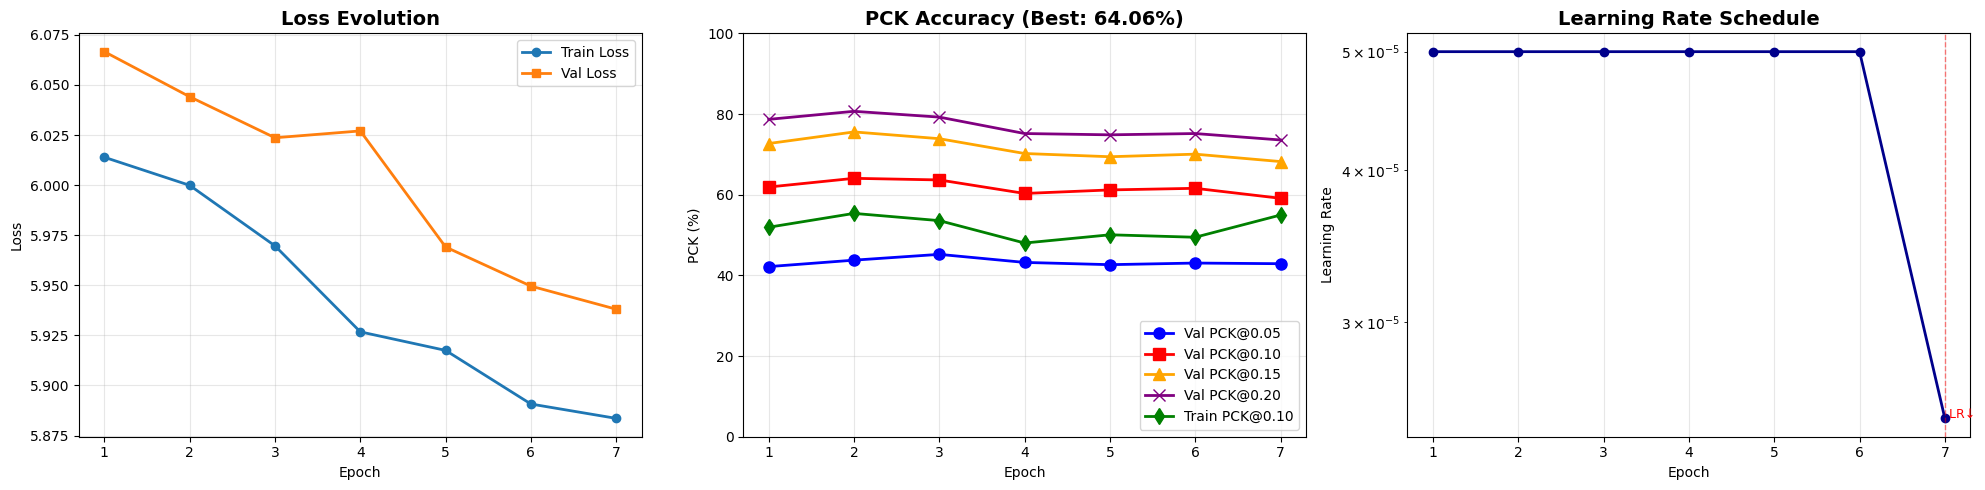


📊 TRAINING SUMMARY
Total Epochs Trained: 7
Validation Epochs: 7
Best Val PCK@0.10: 64.06%
Initial LR: 5.00e-05
Final LR: 2.50e-05
LR Reductions: 1
Final Train Loss: 5.8836
Final Val Loss: 5.9381



In [ ]:
plot_training_history(history)

In [ ]:
#        ======= chosen model: sam =======
MODEL_NAME = 'sam'

# Training hyperparameters
NUM_EPOCHS = 3
BATCH_SIZE = 1 # better to keep low batch size with sam training
LEARNING_RATE = 5e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # True = also unfreeze neck layer

# Debug mode (set to None for full training)
DEBUG_BATCHES = 250  # Use None for full training, or a number like 5 for quick test

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512
# ... Inside the 'elif sam' block ...
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 512

    import torch.nn.functional as F

    # Get current positional embedding (typically 64x64 for SAM)
    old_pos_embed = model.image_encoder.pos_embed
    new_grid_size = target_size // patch_size  # 512 / 16 = 32

    # Check if interpolation is needed
    if old_pos_embed.shape[1] != new_grid_size:
        print(f"--- Adapting SAM: {old_pos_embed.shape[1]} -> {new_grid_size} ---")

        # Reshape to [Batch, Channel, Height, Width] for interpolation
        pos_embed_reshaped = old_pos_embed.permute(0, 3, 1, 2)

        # Bicubic interpolation to resize spatial grid
        new_pos_embed = F.interpolate(
            pos_embed_reshaped,
            size=(new_grid_size, new_grid_size),
            mode='bicubic',
            align_corners=False
        )

        # Restore to [Batch, Height, Width, Channel] and update model
        model.image_encoder.pos_embed = torch.nn.Parameter(new_pos_embed.permute(0, 2, 3, 1))
        print("--- SAM adaptation complete! ---")
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}. Use 'dinov2', 'dinov3', or 'sam'.")

print(f"Model: {MODEL_NAME} | Device: {device} | Patch size: {patch_size}")